# Предсказание следующего товара

Идея: смотрим, какой товар пользователи чаще всего просматривали после каждого конкретного товара, и предлагаем самые частые варианты.

In [1]:
import json
import collections
import matplotlib.pyplot as plt

# ── Загрузка данных ──────────────────────────────────────────────────────────
sessions = []
with open("sessions.jsonl") as f:
    for line in f:
        line = line.strip()
        if line:
            sessions.append(json.loads(line))

print(f"Загружено сессий: {len(sessions)}")
print(f"Первая сессия:    {sessions[0]}")

Загружено сессий: 2565
Первая сессия:    [380, 293, 262, 114, 123, 345, 335, 245, 272, 293, 233, 302, 247, 290, 260, 341, 293]


---
## Шаг 1 · Смотрим на данные

In [2]:
# ── Базовая статистика ───────────────────────────────────────────────────────
lengths      = [len(s) for s in sessions]
all_items    = [item for s in sessions for item in s]
unique_items = set(all_items)
freq         = collections.Counter(all_items)

print("=" * 40)
print(f"Число сессий:          {len(sessions)}")
print(f"Уникальных товаров:    {len(unique_items)}")
print(f"Всего просмотров:      {len(all_items)}")
print(f"Мин. длина сессии:     {min(lengths)}")
print(f"Макс. длина сессии:    {max(lengths)}")
print(f"Средняя длина сессии:  {sum(lengths)/len(lengths):.2f}")
print(f"Медианная длина:       {sorted(lengths)[len(lengths)//2]}")
print("=" * 40)

print("\nТоп-10 самых популярных товаров:")
for rank, (item, cnt) in enumerate(freq.most_common(10), 1):
    pct = cnt / len(all_items) * 100
    print(f"  {rank:2d}. item {item:4d} — {cnt:5d} просмотров ({pct:.2f}%)")

# Проверка: есть ли товары, встречающиеся ровно один раз
hapax = sum(1 for v in freq.values() if v == 1)
print(f"\nТоваров, встречающихся только 1 раз: {hapax}")

Число сессий:          2565
Уникальных товаров:    400
Всего просмотров:      26843
Мин. длина сессии:     3
Макс. длина сессии:    20
Средняя длина сессии:  10.47
Медианная длина:       9

Топ-10 самых популярных товаров:
   1. item   54 —  2914 просмотров (10.86%)
   2. item  335 —  1691 просмотров (6.30%)
   3. item   53 —  1223 просмотров (4.56%)
   4. item  114 —  1067 просмотров (3.97%)
   5. item  260 —   833 просмотров (3.10%)
   6. item  293 —   736 просмотров (2.74%)
   7. item  380 —   571 просмотров (2.13%)
   8. item  212 —   510 просмотров (1.90%)
   9. item  329 —   492 просмотров (1.83%)
  10. item  257 —   450 просмотров (1.68%)

Товаров, встречающихся только 1 раз: 0


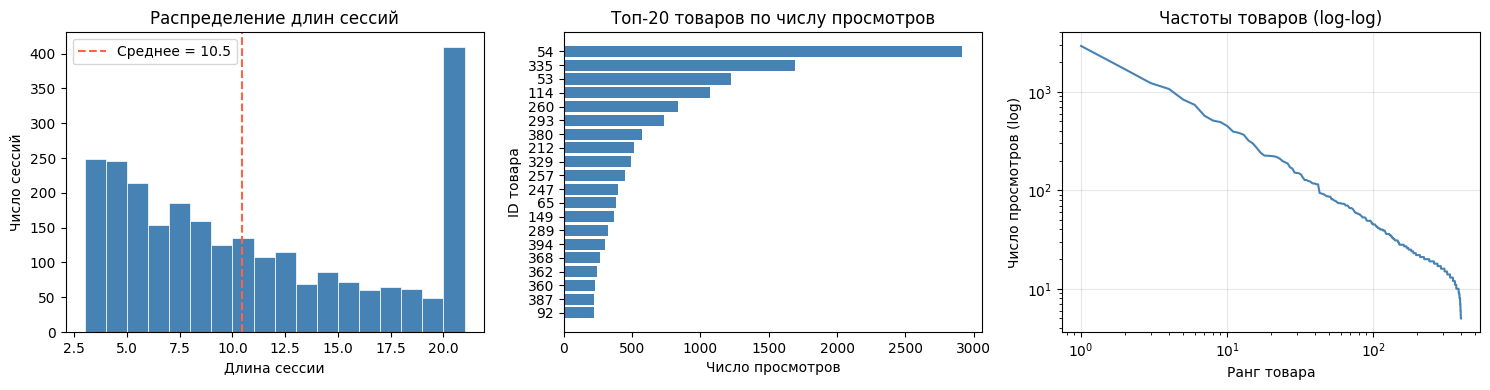

Графики сохранены в eda_plots.png


In [ ]:
# ── Графики ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1) Распределение длин сессий
ax = axes[0]
bins = range(min(lengths), max(lengths) + 2)
ax.hist(lengths, bins=bins, color='steelblue', edgecolor='white', linewidth=0.5)
ax.axvline(sum(lengths)/len(lengths), color='tomato', linestyle='--',
           linewidth=1.5, label=f'Среднее = {sum(lengths)/len(lengths):.1f}')
ax.set_title('Распределение длин сессий')
ax.set_xlabel('Длина сессии')
ax.set_ylabel('Число сессий')
ax.legend()

# 2) Топ-20 товаров по частоте
ax = axes[1]
top20 = freq.most_common(20)
items_ids = [str(x[0]) for x in top20]
items_cnt = [x[1] for x in top20]
ax.barh(items_ids[::-1], items_cnt[::-1], color='steelblue')
ax.set_title('Топ-20 товаров по числу просмотров')
ax.set_xlabel('Число просмотров')
ax.set_ylabel('ID товара')

# 3) Распределение частот всех товаров (log-шкала)
ax = axes[2]
all_counts = sorted(freq.values(), reverse=True)
ax.plot(range(1, len(all_counts)+1), all_counts, color='steelblue')
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_title('Частоты товаров (log-log)')
ax.set_xlabel('Ранг товара')
ax.set_ylabel('Число просмотров (log)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=120, bbox_inches='tight')
plt.show()
print("Графики сохранены в eda_plots.png")

In [4]:
# ── Интересные наблюдения ────────────────────────────────────────────────────
# 1. Повторы товаров внутри одной сессии
sessions_with_repeats = sum(1 for s in sessions if len(s) != len(set(s)))
pct_repeats = sessions_with_repeats / len(sessions) * 100
print(f"Сессий с повторными просмотрами одного товара: "
      f"{sessions_with_repeats} ({pct_repeats:.1f}%)")

# 2. Самый частый товар занимает непропорционально большую долю
top1_item, top1_cnt = freq.most_common(1)[0]
total = len(all_items)
print(f"\nСамый популярный товар (item {top1_item}) — "
      f"{top1_cnt}/{total} просмотров ({top1_cnt/total*100:.1f}%)")

# 3. Концентрация: топ-10 товаров vs все остальные
top10_views = sum(cnt for _, cnt in freq.most_common(10))
print(f"Топ-10 товаров охватывают {top10_views/total*100:.1f}% всех просмотров "
      f"(при 400 уникальных товарах — явная Парето-концентрация)")

# 4. Минимальная длина сессии
print(f"\nВсе сессии длиной >= 3 (по условию задачи): {min(lengths) >= 3}")

Сессий с повторными просмотрами одного товара: 1552 (60.5%)

Самый популярный товар (item 54) — 2914/26843 просмотров (10.9%)
Топ-10 товаров охватывают 39.1% всех просмотров (при 400 уникальных товарах — явная Парето-концентрация)

Все сессии длиной >= 3 (по условию задачи): True


**Что заметила в данных:**

1. Несколько товаров встречаются очень часто, остальные — редко. Топ-10 товаров — это почти 40% всех просмотров, хотя всего товаров 400.
2. В 60% сессий пользователь возвращался к одному и тому же товару — смотрел его несколько раз.
3. Длины сессий в основном около 10, коротких или очень длинных почти нет.
4. Все 400 товаров встречаются больше одного раза — нет таких, которые никто почти не смотрел.

---
## Шаг 2 · Разбивка на обучение и тест

In [ ]:
def train_test_split(
    sessions: list[list[int]],
) -> tuple[list[list[int]], list[int]]:
    """
    Для каждой сессии:
      - все товары кроме последнего это обучающая история
      - последний товар это тестовая цель
    """
    train_sessions = [session[:-1] for session in sessions]
    test_targets   = [session[-1]  for session in sessions]
    return train_sessions, test_targets


train_sessions, test_targets = train_test_split(sessions)

print("Проверка разбиения:")
print(f"  Исходная сессия [0]: {sessions[0]}")
print(f"  Train часть [0]:     {train_sessions[0]}")
print(f"  Test target [0]:     {test_targets[0]}")
assert test_targets[0] == sessions[0][-1]
assert train_sessions[0] == sessions[0][:-1]
print("  ✓ Разбиение корректно")

Проверка разбиения:
  Исходная сессия [0]: [380, 293, 262, 114, 123, 345, 335, 245, 272, 293, 233, 302, 247, 290, 260, 341, 293]
  Train часть [0]:     [380, 293, 262, 114, 123, 345, 335, 245, 272, 293, 233, 302, 247, 290, 260, 341]
  Test target [0]:     293
  ✓ Разбиение корректно


---
## Шаг 3 · Считаем, какой товар за каким идёт

In [7]:
def build_transition_graph(
    train_sessions: list[list[int]]
) -> dict[int, collections.Counter]:
    transitions = collections.defaultdict(collections.Counter)
    for sess in train_sessions:
        for a, b in zip(sess, sess[1:]):   # пары соседних товаров
            transitions[a][b] += 1
    return transitions


transitions = build_transition_graph(train_sessions)

# Статистика графа
n_edges     = sum(len(v) for v in transitions.values())
n_nodes     = len(transitions)
print(f"Вершин в графе (товаров с исходящими рёбрами): {n_nodes}")
print(f"Уникальных направленных рёбер:                 {n_edges}")
print(f"Теоретически возможных рёбер (400²):           {400**2}")
print(f"Плотность графа:                               {n_edges/400**2:.4f}")

print("\nПример: топ 5 переходов из товара 54 (самый популярный):")
for item, cnt in transitions[54].most_common(5):
    total_from_54 = sum(transitions[54].values())
    print(f"  54 -> {item:3d}: {cnt:4d} раз, P = {cnt/total_from_54:.3f}")

Вершин в графе (товаров с исходящими рёбрами): 400
Уникальных направленных рёбер:                 8620
Теоретически возможных рёбер (400²):           160000
Плотность графа:                               0.0539

Пример: топ 5 переходов из товара 54 (самый популярный):
  54 ->  53:  407 раз, P = 0.169
  54 -> 329:  210 раз, P = 0.087
  54 -> 335:  171 раз, P = 0.071
  54 -> 114:   78 раз, P = 0.032
  54 -> 338:   70 раз, P = 0.029


In [8]:
def transition_probability(i: int, j: int, transitions: dict) -> float:
    """
    P(j | i) — вероятность перехода от i к j.
    Обработка граничных случаев:
      - Если i никогда не встречался в train -> возвращаем 0.0.
      - Если переход i→j никогда не наблюдался -> возвращаем 0.0.
    """
    if i not in transitions:
        return 0.0
    total = sum(transitions[i].values())
    return transitions[i][j] / total


# Примеры
print("P(335 | 54) =", transition_probability(54, 335, transitions))
print("P(999 | 54) =", transition_probability(54, 999, transitions))  # несуществующий
print("P(54  | 0)  =", transition_probability(0, 54, transitions))    # i=0 нет в train

P(335 | 54) = 0.07104279185708351
P(999 | 54) = 0.0
P(54  | 0)  = 0.15384615384615385


---
## Шаг 4 · Рекомендации
    Логика:
      1. Берём последний товар из истории.
      2. Ранжируем его соседей по вероятности перехода P(j | anchor).
      3. Исключаем сам последний товар из выдачи.
      4. Если соседей не хватает до k — добираем из global_popular.
      5. Если последний товар вообще не встречался в train — используем global_popular.

  

In [13]:
# Глобальный рейтинг популярности (для fallback)
train_item_freq   = collections.Counter(item for s in train_sessions for item in s)
global_popular    = [item for item, _ in train_item_freq.most_common()]


def recommend(
    history: list[int],
    transitions: dict,
    global_popular: list[int],
    k: int = 10,
) -> list[int]:

#Возвращает топ-k рекомендаций по истории просмотров.

    anchor = history[-1]
    recs   = []

    if anchor in transitions:
        # Сортируем по убыванию числа переходов (пропорционально вероятности)
        ranked = sorted(transitions[anchor].items(), key=lambda x: -x[1])
        recs   = [item for item, _ in ranked if item != anchor]

    # Добираем популярными товарами, которых ещё нет в recs
    recs_set = set(recs)
    for item in global_popular:
        if len(recs) >= k:
            break
        if item not in recs_set and item != anchor:
            recs.append(item)
            recs_set.add(item)

    return recs[:k]


# Пример
example_history = train_sessions[0]
example_recs    = recommend(example_history, transitions, global_popular)
print(f"История:          {example_history}")
print(f"Последний товар:            {example_history[-1]}")
print(f"Рекомендации:     {example_recs}")
print(f"Истинный target:  {test_targets[0]}")
print(f"Попадание:        {'+' if test_targets[0] in example_recs else '+'}")

История:          [380, 293, 262, 114, 123, 345, 335, 245, 272, 293, 233, 302, 247, 290, 260, 341]
Последний товар:            341
Рекомендации:     [92, 149, 54, 287, 7, 212, 12, 260, 380, 335]
Истинный target:  293
Попадание:        +


---
## Шаг 5 · Проверяем, насколько хорошо работает

In [14]:
def hit_at_k(
    recommendations: list[list[int]],
    true_items: list[int],
    k: int = 10,
) -> float:
    """
    Вычисление Hit@K.

    hit_i = 1, если true_items[i] принадлежит recommendations[i][:k]
    Hit@K = mean(hit_i)
    """
    assert len(recommendations) == len(true_items)
    
    hits = sum(
        1 for recs, true_item in zip(recommendations, true_items)
        if true_item in recs[:k]
    )
    return hits / len(true_items)


# ── Переходная модель ────────────────────────────────────────────────────────
transition_recs = [
    recommend(sess, transitions, global_popular)
    for sess in train_sessions
]
hit_transition = hit_at_k(transition_recs, test_targets)

# ── Бейзлайн: всегда топ 10 популярных ──────────────────────────────────────
top10_popular   = global_popular[:10]
baseline_recs   = [top10_popular] * len(test_targets)
hit_baseline    = hit_at_k(baseline_recs, test_targets)

print("Результаты оценки на тестовом наборе")
print("=" * 40)
print(f"  Transition model   Hit@10: {hit_transition:.4f}")
print(f"  Popular baseline   Hit@10: {hit_baseline:.4f}")
print(f"  Улучшение над бейзлайном:  +{(hit_transition - hit_baseline):.4f}")
print("=" * 40)

Результаты оценки на тестовом наборе
  Transition model   Hit@10: 0.5142
  Popular baseline   Hit@10: 0.3840
  Улучшение над бейзлайном:  +0.1302


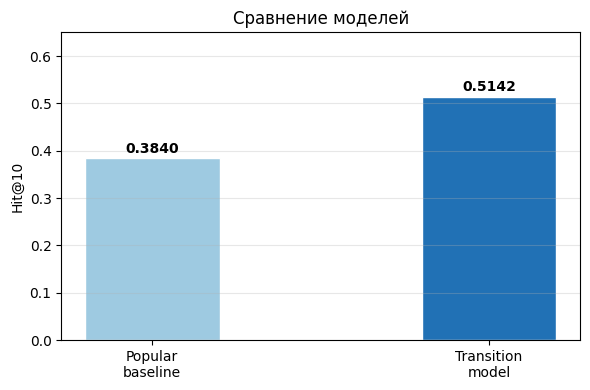

In [15]:
# ── График сравнения ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))

models  = ['Popular\nbaseline', 'Transition\nmodel']
scores  = [hit_baseline, hit_transition]
colors  = ['#9ecae1', '#2171b5']

bars = ax.bar(models, scores, color=colors, width=0.4, edgecolor='white')
for bar, score in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f'{score:.4f}', ha='center', va='bottom', fontweight='bold')

ax.set_ylim(0, 0.65)
ax.set_ylabel('Hit@10')
ax.set_title('Сравнение моделей')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

In [17]:
# ── Анализ ошибок ────────────────────────────────────────────────────────────
miss_no_transition  = 0  # последний товар не встречался в train
miss_rare_anchor    = 0  # последний товар встречался, но target не в его соседях
miss_target_popular = 0  # target есть в top10, но модель промахнулась

for sess, target, recs in zip(train_sessions, test_targets, transition_recs):
    if target in recs:
        continue                         # попадание не анализируем
    anchor = sess[-1]
    if anchor not in transitions:
        miss_no_transition += 1
    elif target not in transitions[anchor]:
        miss_rare_anchor += 1
    if target in top10_popular:
        miss_target_popular += 1

total_misses = len(test_targets) - int(hit_transition * len(test_targets))
print(f"Всего промахов: {total_misses}")
print(f"  Последний товар не встречался в train:        {miss_no_transition}")
print(f"  Переход anchor→target не наблюдался: {miss_rare_anchor}")
print(f"  Target входил в топ-10 popular:      {miss_target_popular}")

Всего промахов: 1246
  Последний товар не встречался в train:        0
  Переход anchor→target не наблюдался: 697
  Target входил в топ-10 popular:      184


---
## Итоги
Большинство промахов это случаи, когда пользователь перешёл к товару, который после данного anchor ранее не наблюдался.
Стратегия fallback на popular частично компенсирует этот пробел

Итак, модель угадывает следующий товар в 51% случаев — это на 13 процентных пунктов лучше, чем просто всем предлагать одно и то же:)
